In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

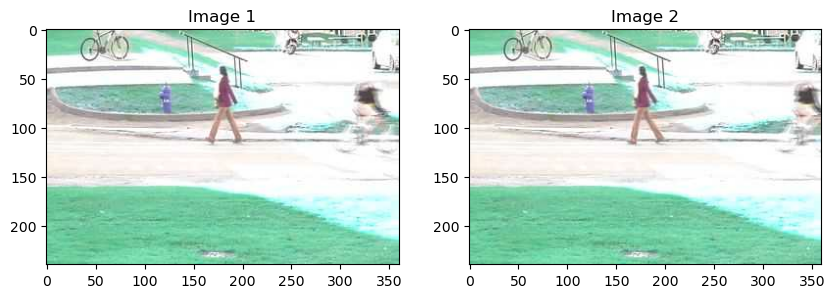

In [21]:
pedestrinan_input_dir = "data/pedestrian/input"

def load_2_images(path, from_idx=1, skip=1):
    idx_6_digits = str(from_idx).zfill(6)
    img1 = cv2.imread(f"{path}/in{idx_6_digits}.jpg")
    img2 = cv2.imread(f"{path}/in{str(from_idx + skip).zfill(6)}.jpg")
    return img1, img2

img1, img2 = load_2_images(pedestrinan_input_dir, from_idx=500, skip=2)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img1)
ax[0].set_title("Image 1")
ax[1].imshow(img2)
ax[1].set_title("Image 2")
plt.show()



Otsu threshold without opening: 54.0
Otsu threshold with opening: 54.0


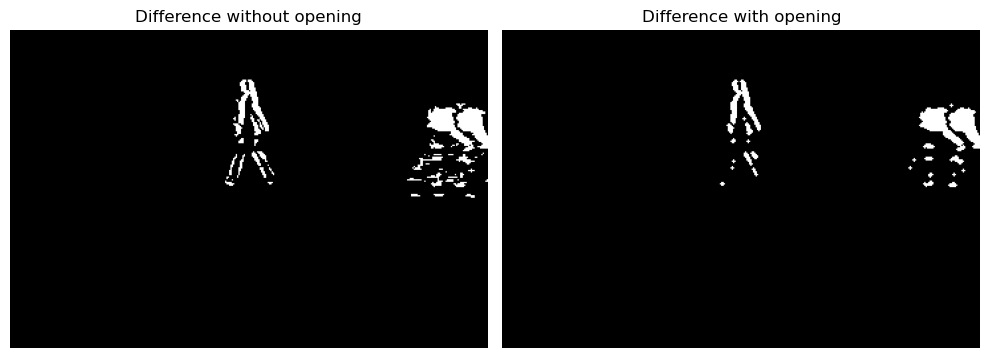

In [31]:
def show_diff(img1, img2, ax=None, with_opening=False):
    diff = cv2.absdiff(img1, img2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    (T, thresh) = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    if with_opening:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    if ax is not None:
        ax.imshow(thresh, cmap="gray")
        ax.axis("off")
        
    return T, thresh

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title("Difference without opening")
T_no_open, _ = show_diff(img1, img2, ax[0], with_opening=False)

ax[1].set_title("Difference with opening")
T_open, _ = show_diff(img1, img2, ax[1], with_opening=True)

print(f"Otsu threshold without opening: {T_no_open}")
print(f"Otsu threshold with opening: {T_open}")
plt.tight_layout()
plt.show()

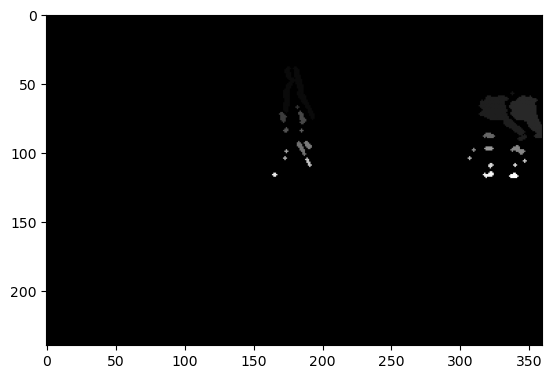

In [32]:

_, thresh = show_diff(img1, img2, with_opening=True)

retval, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

plt.imshow((labels / retval) * 255, cmap="gray")

Largest component index: 3
Largest component area: 421


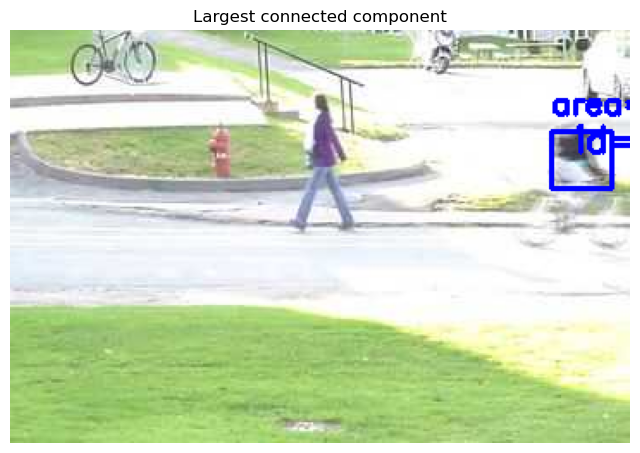

In [33]:
# Wizualizacja największego obiektu z connectedComponentsWithStats
I_VIS = img1.copy()  # kopia obrazu wejściowego

if stats.shape[0] > 1:  # czy istnieją obiekty poza tłem
    # Szybszy i czytelniejszy wybór po kolumnie pola (CC_STAT_AREA), bez ręcznego "4"
    pi = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    x = stats[pi, cv2.CC_STAT_LEFT]
    y = stats[pi, cv2.CC_STAT_TOP]
    w = stats[pi, cv2.CC_STAT_WIDTH]
    h = stats[pi, cv2.CC_STAT_HEIGHT]
    area = stats[pi, cv2.CC_STAT_AREA]

    # Bounding box
    cv2.rectangle(I_VIS, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Pole obiektu
    cv2.putText(
        I_VIS, f"area={area}", (x, max(0, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
    )

    # Indeks obiektu przy centroidzie
    cx, cy = centroids[pi].astype(int)
    cv2.putText(
        I_VIS, f"id={pi}", (cx, cy),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2
    )

    print(f"Largest component index: {pi}")
    print(f"Largest component area: {area}")
else:
    print("No foreground objects detected.")

# cv2 rysuje w BGR, a matplotlib oczekuje RGB
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(I_VIS, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Largest connected component")
plt.show()